# Proyek Analisis Data: E-Commerce Public Dataset

- **Nama:** [Isi Nama Anda]
- **Email:** [Isi Email Anda]
- **ID Dicoding:** [Isi ID Dicoding Anda]

## Tujuan Proyek
Proyek ini bertujuan menganalisis data transaksi e-commerce untuk menemukan pola penjualan, perilaku pelanggan, dan faktor operasional yang memengaruhi kepuasan pelanggan. Hasil analisis kemudian akan dirangkum dalam dashboard interaktif menggunakan Streamlit.


## Menentukan Pertanyaan Bisnis

Berdasarkan karakteristik dataset, proyek ini akan menjawab pertanyaan bisnis berikut.

1. **Kategori produk apa yang memberikan kontribusi terbesar terhadap pendapatan dan jumlah pesanan?**
2. **Bagaimana performa pengiriman memengaruhi tingkat kepuasan pelanggan?**

Sebagai analisis lanjutan untuk memperkaya insight, proyek ini juga menambahkan:
- **RFM Analysis** untuk mengelompokkan pelanggan berdasarkan perilaku belanja.
- **Geospatial analysis sederhana** untuk melihat persebaran kontribusi pendapatan per state pelanggan.


## Import Semua Packages/Library yang Digunakan

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)


## Data Wrangling

### Gathering Data

In [2]:

# Memuat seluruh dataset
customers_df = pd.read_csv("data/customers_dataset.csv")
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
orders_df = pd.read_csv("data/orders_dataset.csv")
product_category_df = pd.read_csv("data/product_category_name_translation.csv")
products_df = pd.read_csv("data/products_dataset.csv")
sellers_df = pd.read_csv("data/sellers_dataset.csv")

dataset_summary = pd.DataFrame({
    "dataset": [
        "customers", "geolocation", "order_items", "order_payments",
        "order_reviews", "orders", "product_category_translation",
        "products", "sellers"
    ],
    "rows": [
        len(customers_df), len(geolocation_df), len(order_items_df), len(order_payments_df),
        len(order_reviews_df), len(orders_df), len(product_category_df), len(products_df), len(sellers_df)
    ],
    "columns": [
        customers_df.shape[1], geolocation_df.shape[1], order_items_df.shape[1], order_payments_df.shape[1],
        order_reviews_df.shape[1], orders_df.shape[1], product_category_df.shape[1], products_df.shape[1], sellers_df.shape[1]
    ]
})

dataset_summary


,dataset,rows,columns
0,customers,99441,5
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,orders,99441,8
6,product_category_translation,71,2
7,products,32951,9
8,sellers,3095,4


**Insight:**
- Dataset terdiri dari **9 file** yang saling terhubung melalui `order_id`, `customer_id`, `product_id`, dan `seller_id`.
- File dengan observasi terbesar adalah `geolocation_dataset.csv`, sehingga perlu penanganan khusus agar efisien saat analisis.
- Struktur data sangat cocok untuk analisis penjualan, perilaku pelanggan, kualitas pengiriman, dan segmentasi pelanggan.


### Assessing Data

In [3]:

def assess_data(df, df_name):
    return pd.DataFrame({
        "dataset": [df_name] * len(df.columns),
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_values": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "duplicate_rows": [df.duplicated().sum()] * len(df.columns),
        "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
    })

assessment_df = pd.concat([
    assess_data(customers_df, "customers"),
    assess_data(geolocation_df, "geolocation"),
    assess_data(order_items_df, "order_items"),
    assess_data(order_payments_df, "order_payments"),
    assess_data(order_reviews_df, "order_reviews"),
    assess_data(orders_df, "orders"),
    assess_data(product_category_df, "product_category_translation"),
    assess_data(products_df, "products"),
    assess_data(sellers_df, "sellers")
], ignore_index=True)

assessment_df


,dataset,column,dtype,missing_values,missing_pct,duplicate_rows,unique_values
0,customers,customer_id,object,0,0.00,0,99441
1,customers,customer_unique_id,object,0,0.00,0,96096
2,customers,customer_zip_code_prefix,int64,0,0.00,0,14994
3,customers,customer_city,object,0,0.00,0,4119
4,customers,customer_state,object,0,0.00,0,27
5,geolocation,geolocation_zip_code_prefix,int64,0,0.00,261831,19015
6,geolocation,geolocation_lat,float64,0,0.00,261831,717360
7,geolocation,geolocation_lng,float64,0,0.00,261831,717613
8,geolocation,geolocation_city,object,0,0.00,261831,8011
9,geolocation,geolocation_state,object,0,0.00,261831,27


**Insight:**
- `orders_df` memiliki missing values pada kolom tanggal pengiriman, yang **wajar** karena tidak semua pesanan berstatus delivered.
- `products_df` memiliki missing values pada beberapa atribut produk dan kategori, sehingga perlu penanganan sebelum analisis kategori.
- `order_reviews_df` memiliki banyak missing values pada kolom komentar ulasan; kolom ini tidak menjadi fokus utama analisis numerik.
- `geolocation_df` memiliki banyak data duplikat pada level baris, sehingga perlu diringkas berdasarkan `zip_code_prefix`.


### Cleaning Data

In [4]:

# Salin dataframe agar data mentah tetap aman
orders_clean = orders_df.copy()
products_clean = products_df.copy()
geolocation_clean = geolocation_df.copy()
reviews_clean = order_reviews_df.copy()
items_clean = order_items_df.copy()

# Ubah kolom tanggal menjadi tipe datetime
datetime_columns_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in datetime_columns_orders:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors="coerce")

items_clean["shipping_limit_date"] = pd.to_datetime(items_clean["shipping_limit_date"], errors="coerce")
reviews_clean["review_creation_date"] = pd.to_datetime(reviews_clean["review_creation_date"], errors="coerce")
reviews_clean["review_answer_timestamp"] = pd.to_datetime(reviews_clean["review_answer_timestamp"], errors="coerce")

# Tambahkan nama kategori bahasa Inggris
products_clean = products_clean.merge(
    product_category_df,
    on="product_category_name",
    how="left"
)
products_clean["product_category_name_english"] = products_clean["product_category_name_english"].fillna("unknown")

# Ringkas geolocation berdasarkan zip code prefix
geo_clean = (
    geolocation_clean
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg({
        "geolocation_lat": "mean",
        "geolocation_lng": "mean",
        "geolocation_city": lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0],
        "geolocation_state": lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
    })
)

# Gabungkan data utama untuk analisis
all_df = (
    items_clean
    .merge(
        orders_clean[[
            "order_id", "customer_id", "order_status", "order_purchase_timestamp",
            "order_delivered_customer_date", "order_estimated_delivery_date"
        ]],
        on="order_id",
        how="left"
    )
    .merge(
        customers_df[[
            "customer_id", "customer_unique_id", "customer_city", "customer_state", "customer_zip_code_prefix"
        ]],
        on="customer_id",
        how="left"
    )
    .merge(
        products_clean[["product_id", "product_category_name_english"]],
        on="product_id",
        how="left"
    )
    .merge(
        reviews_clean[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
)

# Fokus analisis utama pada order yang sudah delivered
main_df = all_df[all_df["order_status"] == "delivered"].copy()

# Feature engineering
main_df["sales"] = main_df["price"] + main_df["freight_value"]
main_df["purchase_month"] = main_df["order_purchase_timestamp"].dt.to_period("M").astype(str)
main_df["delivery_time_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_purchase_timestamp"]
).dt.days
main_df["delivery_delay_days"] = (
    main_df["order_delivered_customer_date"] - main_df["order_estimated_delivery_date"]
).dt.days
main_df["is_late"] = main_df["delivery_delay_days"] > 0

main_df["delay_category"] = pd.cut(
    main_df["delivery_delay_days"],
    bins=[-np.inf, -1, 0, 3, 7, np.inf],
    labels=["Lebih cepat", "Tepat waktu", "Terlambat 1-3 hari", "Terlambat 4-7 hari", "Terlambat >7 hari"]
)

# Tambahkan informasi geolokasi pelanggan
main_df = main_df.merge(
    geo_clean[["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"]],
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

# Simpan data bersih untuk dashboard
main_df.to_csv("dashboard/main_data.csv", index=False)

main_df.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,customer_zip_code_prefix,product_category_name_english,review_score,sales,purchase_month,delivery_time_days,delivery_delay_days,is_late,delay_category,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,28013,cool_stuff,5.00,72.19,2017-09,7.00,-9.00,False,Lebih cepat,"28,013.00",-21.76,-41.31
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,15775,pet_shop,4.00,259.83,2017-04,16.00,-3.00,False,Lebih cepat,"15,775.00",-20.22,-50.90
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,35661,furniture_decor,5.00,216.87,2018-01,7.00,-14.00,False,Lebih cepat,"35,661.00",-19.87,-44.59
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,12952,perfumery,4.00,25.78,2018-08,6.00,-6.00,False,Lebih cepat,"12,952.00",-23.09,-46.61
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,13226,garden_tools,5.00,218.04,2017-02,25.00,-16.00,False,Lebih cepat,"13,226.00",-23.24,-46.83


**Insight:**
- Data utama analisis difokuskan pada **pesanan yang sudah delivered** agar metrik penjualan dan pengiriman lebih konsisten.
- Dibuat beberapa fitur baru seperti `sales`, `purchase_month`, `delivery_time_days`, `delivery_delay_days`, dan `is_late`.
- File `dashboard/main_data.csv` telah dihasilkan dari proses cleaning sehingga bisa langsung digunakan kembali saat membuat dashboard Streamlit.


## Exploratory Data Analysis (EDA)

### Ringkasan metrik utama

In [5]:

summary_metrics = pd.DataFrame({
    "metric": [
        "Total delivered orders",
        "Total unique customers",
        "Total revenue",
        "Average review score",
        "Late delivery percentage"
    ],
    "value": [
        main_df["order_id"].nunique(),
        main_df["customer_unique_id"].nunique(),
        round(main_df["sales"].sum(), 2),
        round(main_df["review_score"].mean(), 2),
        round(main_df["is_late"].mean() * 100, 2)
    ]
})

summary_metrics


,metric,value
0,Total delivered orders,"96,478.00"
1,Total unique customers,"93,358.00"
2,Total revenue,"15,489,665.55"
3,Average review score,4.08
4,Late delivery percentage,6.58


### Eksplorasi kategori, pengiriman, dan state

In [6]:

monthly_performance = (
    main_df.groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("sales", "sum")
    )
    .reset_index()
)

top_categories = (
    main_df.groupby("product_category_name_english")
    .agg(
        total_revenue=("sales", "sum"),
        total_orders=("order_id", "nunique"),
        avg_review=("review_score", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

delivery_review = (
    main_df.dropna(subset=["delay_category", "review_score"])
    .groupby("delay_category", observed=True)
    .agg(
        avg_review=("review_score", "mean"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

state_performance = (
    main_df.groupby("customer_state")
    .agg(
        total_revenue=("sales", "sum"),
        total_orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        late_order_pct=("is_late", "mean"),
        avg_lat=("geolocation_lat", "mean"),
        avg_lng=("geolocation_lng", "mean")
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

display(top_categories)
display(delivery_review)
display(state_performance.head(10))


,total_revenue,total_orders,avg_review
product_category_name_english,,,
health_beauty,"1,417,268.99",8647,4.19
watches_gifts,"1,265,552.91",5495,4.07
bed_bath_table,"1,241,489.78",9272,3.92
sports_leisure,"1,124,637.43",7530,4.17
computers_accessories,"1,041,314.27",6530,3.98
furniture_decor,"888,357.07",6307,3.95
housewares,"761,055.43",5743,4.11
cool_stuff,"693,721.94",3559,4.19
auto,"671,019.97",3810,4.12


,delay_category,avg_review,total_orders
0,Lebih cepat,4.21,88163
1,Tepat waktu,3.98,1280
2,Terlambat 1-3 hari,3.23,1852
3,Terlambat 4-7 hari,2.09,1748
4,Terlambat >7 hari,1.70,2781


,customer_state,total_revenue,total_orders,avg_review,late_order_pct,avg_lat,avg_lng
25,SP,"5,799,283.95",40501,4.18,0.04,-23.17,-47.05
18,RJ,"2,063,593.64",12350,3.87,0.12,-22.76,-43.18
10,MG,"1,826,486.53",11354,4.12,0.04,-19.92,-44.44
22,RS,"865,877.26",5345,4.09,0.06,-29.71,-51.95
17,PR,"785,095.06",4923,4.14,0.04,-24.79,-50.78
23,SC,"597,067.83",3546,4.05,0.08,-27.25,-49.57
4,BA,"593,408.37",3256,3.86,0.12,-13.02,-39.47
6,DF,"348,601.41",2080,4.06,0.06,-15.81,-47.97
8,GO,"337,665.51",1957,4.04,0.06,-16.62,-49.33
7,ES,"318,466.51",1995,4.02,0.11,-20.15,-40.49


**Insight:**
- Pendapatan dan jumlah pesanan tidak tersebar merata; hanya beberapa kategori dan state yang menjadi kontributor utama.
- Sebagian besar pengiriman tiba lebih cepat dari estimasi, dan pola ini tampak berhubungan dengan review yang lebih tinggi.
- Insight awal dari EDA menunjukkan bahwa kombinasi dimensi **produk**, **pengiriman**, dan **lokasi pelanggan** paling berpengaruh dalam menjawab pertanyaan bisnis.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang memberikan kontribusi terbesar terhadap pendapatan dan jumlah pesanan?

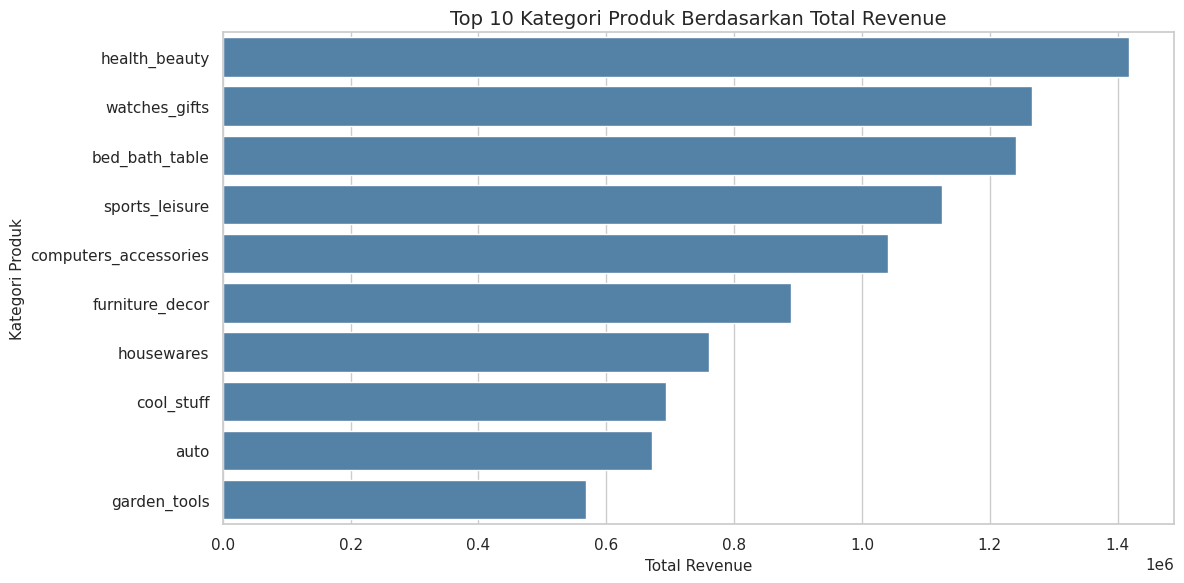

In [7]:

# Visualisasi 1: Top 10 kategori berdasarkan revenue
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_categories.reset_index(),
    x="total_revenue",
    y="product_category_name_english",
    color="steelblue"
)
plt.title("Top 10 Kategori Produk Berdasarkan Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Kategori Produk")
plt.tight_layout()
plt.show()


**Insight:**
- Kategori seperti **health_beauty**, **watches_gifts**, dan **bed_bath_table** merupakan kontributor pendapatan tertinggi.
- Kategori-kategori ini dapat menjadi prioritas untuk strategi promosi, pengelolaan stok, dan optimasi pengalaman pelanggan.


### Pertanyaan 2: Bagaimana performa pengiriman memengaruhi tingkat kepuasan pelanggan?

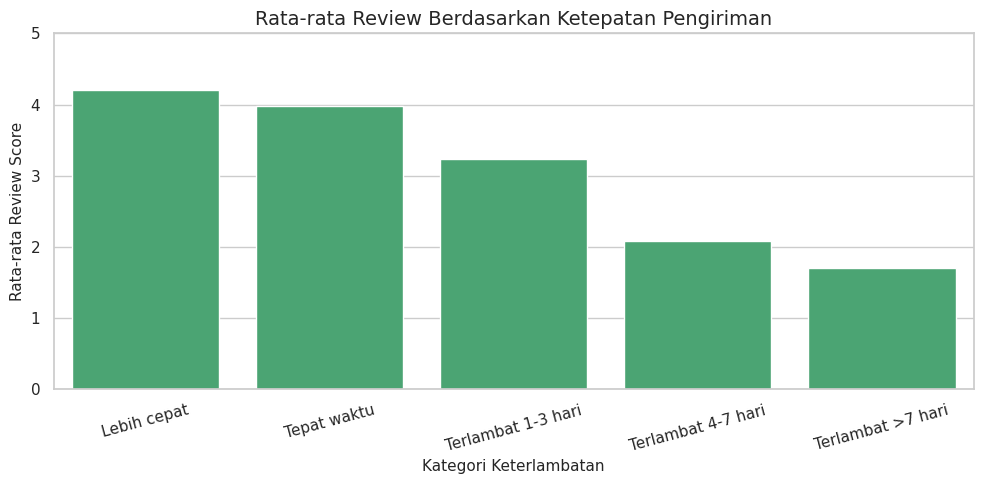

In [8]:

# Visualisasi 2: Rata-rata review berdasarkan ketepatan pengiriman
plt.figure(figsize=(10, 5))
sns.barplot(
    data=delivery_review,
    x="delay_category",
    y="avg_review",
    color="mediumseagreen"
)
plt.title("Rata-rata Review Berdasarkan Ketepatan Pengiriman")
plt.xlabel("Kategori Keterlambatan")
plt.ylabel("Rata-rata Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Insight:**
- Pesanan yang tiba **lebih cepat** memiliki rata-rata review paling tinggi.
- Semakin besar keterlambatan pengiriman, rata-rata review turun tajam. Ini menunjukkan bahwa performa logistik sangat memengaruhi kepuasan pelanggan.


### Visualisasi pendukung: tren pesanan bulanan

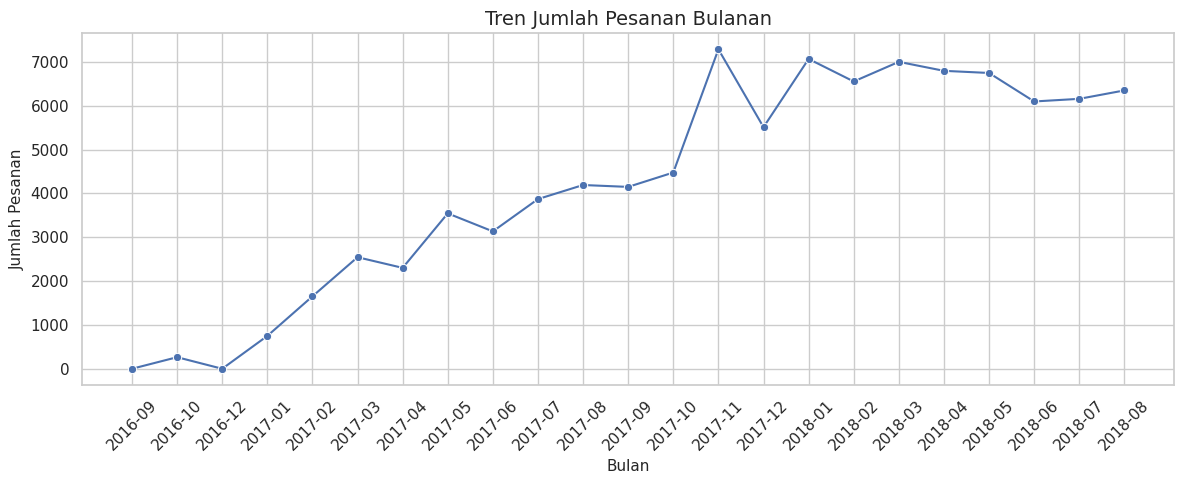

In [9]:

# Visualisasi 3: Tren jumlah pesanan bulanan
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_performance, x="purchase_month", y="total_orders", marker="o")
plt.title("Tren Jumlah Pesanan Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Pesanan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:**
- Terdapat pertumbuhan pesanan yang kuat menuju akhir 2017 hingga pertengahan 2018.
- Pola ini bisa menjadi acuan untuk menyusun strategi promosi musiman dan perencanaan kapasitas operasional.


## Analisis Lanjutan (Advanced Analysis)

Pada proyek ini digunakan dua teknik analisis lanjutan yang relevan dengan konteks bisnis e-commerce:

1. **RFM Analysis**  
   Digunakan untuk mengelompokkan pelanggan berdasarkan:
   - **Recency**: seberapa baru pelanggan melakukan transaksi,
   - **Frequency**: seberapa sering pelanggan bertransaksi,
   - **Monetary**: seberapa besar nilai transaksi pelanggan.

2. **Geospatial Analysis Sederhana**  
   Digunakan untuk melihat persebaran kontribusi pendapatan per state pelanggan berdasarkan koordinat rata-rata dari `zip_code_prefix`.


### RFM Analysis

In [10]:

# RFM Analysis
rfm_df = (
    main_df.groupby("customer_unique_id")
    .agg(
        last_purchase=("order_purchase_timestamp", "max"),
        frequency=("order_id", "nunique"),
        monetary=("sales", "sum")
    )
    .reset_index()
)

snapshot_date = main_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
rfm_df["recency"] = (snapshot_date - rfm_df["last_purchase"]).dt.days

rfm_df["r_score"] = pd.qcut(
    rfm_df["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]
).astype(int)
rfm_df["f_score"] = pd.qcut(
    rfm_df["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
).astype(int)
rfm_df["m_score"] = pd.qcut(
    rfm_df["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]
).astype(int)

def rfm_segment(row):
    if row["r_score"] >= 4 and row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Best Customers"
    elif row["r_score"] >= 3 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "Loyal Customers"
    elif row["r_score"] >= 4 and row["f_score"] <= 2:
        return "Recent Customers"
    elif row["r_score"] <= 2 and row["f_score"] >= 3:
        return "At Risk"
    else:
        return "Others"

rfm_df["segment"] = rfm_df.apply(rfm_segment, axis=1)

rfm_summary = (
    rfm_df.groupby("segment")
    .agg(
        total_customers=("customer_unique_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .sort_values("total_customers", ascending=False)
)

rfm_summary


,total_customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Others,35394,262.65,1.00,121.25
At Risk,22357,393.94,1.05,168.45
Recent Customers,14984,90.88,1.00,163.45
Loyal Customers,14183,152.60,1.05,208.65
Best Customers,6440,90.71,1.18,314.23


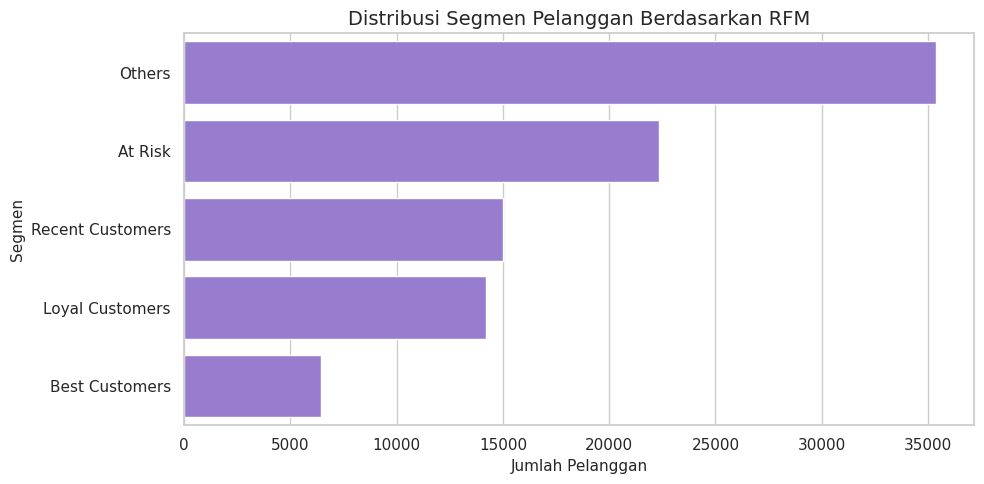

In [11]:

plt.figure(figsize=(10, 5))
rfm_plot = rfm_df["segment"].value_counts().reset_index()
rfm_plot.columns = ["segment", "count"]
sns.barplot(
    data=rfm_plot,
    x="count",
    y="segment",
    color="mediumpurple"
)
plt.title("Distribusi Segmen Pelanggan Berdasarkan RFM")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen")
plt.tight_layout()
plt.show()


**Insight:**
- Segmentasi RFM membantu membedakan pelanggan bernilai tinggi, pelanggan loyal, pelanggan baru, dan pelanggan yang mulai berisiko churn.
- Segmen **Best Customers** dan **Loyal Customers** dapat menjadi target program retensi, sedangkan segmen **At Risk** dapat ditindaklanjuti dengan kampanye reaktivasi.


### Geospatial Analysis Sederhana

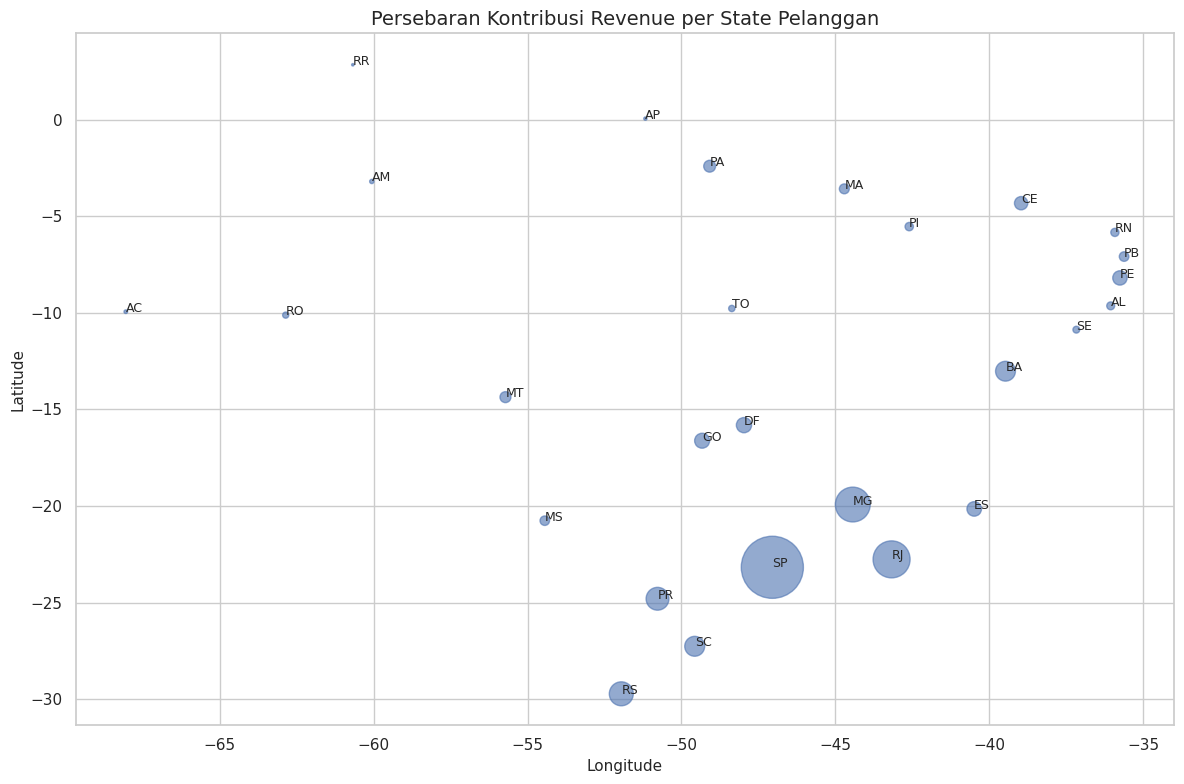

,customer_state,total_revenue,total_orders,avg_lat,avg_lng
25,SP,"5,799,283.95",40501,-23.17,-47.05
18,RJ,"2,063,593.64",12350,-22.76,-43.18
10,MG,"1,826,486.53",11354,-19.92,-44.44
22,RS,"865,877.26",5345,-29.71,-51.95
17,PR,"785,095.06",4923,-24.79,-50.78
23,SC,"597,067.83",3546,-27.25,-49.57
4,BA,"593,408.37",3256,-13.02,-39.47
6,DF,"348,601.41",2080,-15.81,-47.97
8,GO,"337,665.51",1957,-16.62,-49.33
7,ES,"318,466.51",1995,-20.15,-40.49


In [12]:

# Geospatial analysis sederhana per state
state_geo = (
    main_df.groupby("customer_state")
    .agg(
        total_revenue=("sales", "sum"),
        total_orders=("order_id", "nunique"),
        avg_lat=("geolocation_lat", "mean"),
        avg_lng=("geolocation_lng", "mean")
    )
    .reset_index()
    .dropna()
)

plt.figure(figsize=(12, 8))
sizes = (state_geo["total_revenue"] / state_geo["total_revenue"].max()) * 2000

plt.scatter(
    state_geo["avg_lng"],
    state_geo["avg_lat"],
    s=sizes,
    alpha=0.6
)

for _, row in state_geo.iterrows():
    plt.text(row["avg_lng"], row["avg_lat"], row["customer_state"], fontsize=9)

plt.title("Persebaran Kontribusi Revenue per State Pelanggan")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

state_geo.sort_values("total_revenue", ascending=False).head(10)


**Insight:**
- Kontribusi pendapatan terbesar terpusat di state besar seperti **SP**, **RJ**, dan **MG**.
- Analisis geografis membantu menunjukkan bahwa fokus ekspansi, promosi, dan optimasi logistik dapat diprioritaskan ke wilayah dengan kontribusi penjualan terbesar.


## Conclusion

Berdasarkan analisis data e-commerce yang telah dilakukan, diperoleh beberapa kesimpulan utama:

1. **Kategori produk dengan kontribusi pendapatan terbesar** didominasi oleh `health_beauty`, `watches_gifts`, dan `bed_bath_table`. Artinya, kategori-kategori ini merupakan mesin pendapatan utama dan layak diprioritaskan dalam strategi bisnis.
2. **Kualitas pengiriman sangat memengaruhi kepuasan pelanggan.** Pesanan yang tiba lebih cepat memiliki rata-rata review yang jauh lebih tinggi dibanding pesanan yang terlambat, terutama ketika keterlambatan melebihi 3 hari.
3. **Analisis RFM** menunjukkan bahwa pelanggan tidak homogen. Ada pelanggan bernilai tinggi yang perlu dipertahankan, pelanggan baru yang perlu dipupuk, dan pelanggan berisiko yang perlu diaktifkan kembali.
4. **Analisis geografis sederhana** menunjukkan bahwa kontribusi penjualan terbesar berasal dari state tertentu, terutama `SP`, `RJ`, dan `MG`, sehingga strategi pemasaran dan logistik dapat diprioritaskan pada wilayah-wilayah tersebut.

Secara keseluruhan, proyek ini menunjukkan bahwa kombinasi analisis produk, operasional pengiriman, perilaku pelanggan, dan lokasi geografis dapat memberikan insight yang kuat untuk mendukung pengambilan keputusan bisnis.
